# **Task 54: Support Vector Machines (SVM) - Bank Note Authentication**

**Student Name:** Qalb E Zahra Mashhadi  
**Program:** NAVTTC — Artificial Intelligence (ML & DL)  

---

## **1. Objective**

The objective of this task is to implement the **Support Vector Machine (SVM)** algorithm to classify **bank notes** as **real** or **forged** based on features like **variance**, **skewness**, and **entropy**.

---

## **2. Learning Outcomes**

* **Linear Separability:** Learned how SVM finds a **line (or hyperplane)** that best separates two classes.  

* **Support Vectors:** Identified points that are **closest to the separation line** and support the **margin**.  

* **Separation Margin:** Understood that SVM aims to **maximize the distance (margin)** between points and the hyperplane to improve prediction accuracy.  

* **Overfitting Identification:** Recognized that if both **training and testing accuracy** are extremely high (e.g., 99–100%), the model may be **overfitting**, memorizing training data and potentially failing on new data.  

---

## **3. Conclusion**

**SVM** is an **advanced classification algorithm** based on **statistical learning theory**. It is highly effective for **complex data** such as forged bank notes. We learned that using **`kernel='linear'`** can solve simple linear problems, while **kernel tricks** are used for more complex, non-linear classification tasks.  

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# --- 1. Dataset Loading ---
# URL for the dataset

data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
col_names = ["variance", "skewness", "curtosis", "entropy", "class"]

# Reading the dataset

bankdata = pd.read_csv(data_url, names=col_names, sep=",", header=None)

In [3]:
# --- 2. Data Exploration ---

print("Dataset Overview:")
print(bankdata.head())
print(f"Class Distribution:\n{bankdata['class'].value_counts(normalize=True)}")

Dataset Overview:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
Class Distribution:
class
0    0.555394
1    0.444606
Name: proportion, dtype: float64


In [4]:
# --- 3. Preprocessing ---
# Dividing data into features (X) and target (y)

X = bankdata.drop('class', axis=1)
y = bankdata['class']

# Splitting data (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [5]:
# --- 4. Training SVM Model ---
# Creating a Linear SVM model

svclassifier = SVC(kernel='linear')
svclassifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
# --- 5. Predictions & Evaluation ---

y_pred = svclassifier.predict(X_test)

print("Model Evaluation (Test Data):")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Model Evaluation (Test Data):
[[146   2]
 [  2 125]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       0.98      0.98      0.98       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



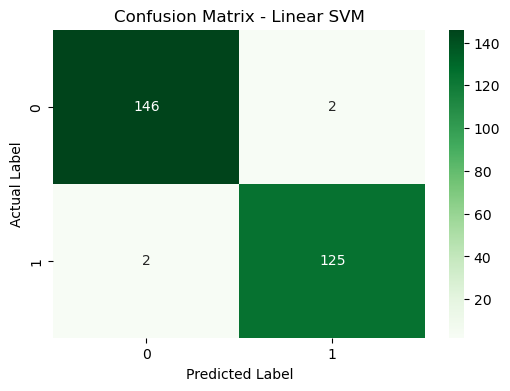

In [7]:
# --- 6. Visualization (Confusion Matrix) ---

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Linear SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()